In [11]:
#Import libraries and load data
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from category_encoders.target_encoder import TargetEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [12]:
transactions = pd.read_csv('transactions_feat.csv')
transactions.head()

,id,date,user_id,card_id,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,...,user_avg_amt_24h,is_first_merchant_visit,is_first_city_visit,is_rare_merchant,user_city,user_region,is_same_city,is_same_region,city_changed,city_change_fast
0,8927991,2022-01-01 00:46:02,0,4639,swipe transaction,55060,polokwane,limpopo,700.0,5812.0,...,179.280,1,1,1,bloemfontein,free state,0,0,0,0
1,20704571,2022-01-01 05:02:57,0,1271,chip transaction,3558,cape town,western cape,8000.0,3640.0,...,89.640,1,1,1,bloemfontein,free state,0,0,1,0
2,18886224,2022-01-01 06:04:41,0,1271,chip transaction,32164,cape town,western cape,8000.0,5813.0,...,1967.760,1,1,1,bloemfontein,free state,0,0,0,0
3,10496251,2022-01-01 07:49:43,0,4639,swipe transaction,60510,durban,kwazulu-natal,4000.0,5912.0,...,1722.600,1,0,1,bloemfontein,free state,0,0,1,0
4,21259165,2022-01-01 14:07:18,0,1271,chip transaction,98648,east london,eastern cape,5200.0,5814.0,...,1433.916,1,1,1,bloemfontein,free state,0,0,1,0


# Leakage & Non-Modelable Feature Removal

In [13]:
LEAKAGE_COLS = [
    "id", "id.1", "id_y",
    "user_id", "card_id", "client_id_y",
    "card_number", "cvv", "expires",
    "address", "zip",
    "description", "errors", "gender"
]

df_model = transactions.drop(columns=[c for c in LEAKAGE_COLS if c in transactions.columns])

In [14]:
int_cols = df_model.select_dtypes(include='int64').columns
print(int_cols)

Index(['merchant_id', 'is_fraud', 'num_cards_issued', 'credit_limit',
       'year_pin_last_changed', 'current_age', 'retirement_age', 'birth_year',
       'birth_month', 'per_capita_income', 'yearly_income', 'total_debt',
       'credit_score', 'num_credit_cards', 'is_negative_amount',
       'transaction_hour', 'transaction_dayofweek', 'is_weekend', 'is_night',
       'risk_score', 'is_high_risk', 'card_age_days', 'is_high_value',
       'unusual_hour', 'unusual_hour_flag', 'is_iqr_outlier', 'is_z_outlier',
       'income_ratio_outlier', 'user_txn_count_24h', 'user_txn_count_7d',
       'is_first_merchant_visit', 'is_first_city_visit', 'is_rare_merchant',
       'is_same_city', 'is_same_region', 'city_changed', 'city_change_fast'],
      dtype='object')


In [15]:
for col in int_cols:
    df_model[col] = pd.to_numeric(df_model[col], downcast='integer')

In [7]:
print(df_model.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8615533 entries, 0 to 8615532
Data columns (total 88 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   date                          object 
 1   use_chip                      object 
 2   merchant_id                   int32  
 3   merchant_city                 object 
 4   merchant_state                object 
 5   mcc                           float64
 6   is_fraud                      int8   
 7   card_brand                    object 
 8   card_type                     object 
 9   has_chip                      object 
 10  num_cards_issued              int8   
 11  credit_limit                  int32  
 12  acct_open_date                object 
 13  year_pin_last_changed         int16  
 14  card_on_dark_web              object 
 15  current_age                   int8   
 16  retirement_age                int8   
 17  birth_year                    int16  
 18  birth_month           

In [7]:
df_model.dtypes

date                object
use_chip            object
merchant_id          int32
merchant_city       object
merchant_state      object
                     ...  
user_region         object
is_same_city          int8
is_same_region        int8
city_changed          int8
city_change_fast      int8
Length: 64, dtype: object

In [9]:
df_model[['card_type', 'risk_category', 'user_city', 'user_region', 'has_chip', 'card_on_dark_web', 'card_brand', 'merchant_state', 'merchant_city', 'use_chip']].head()

,card_type,risk_category,user_city,user_region,has_chip,card_on_dark_web,card_brand,merchant_state,merchant_city,use_chip
0,Credit,Medium,bloemfontein,free state,YES,No,Visa,limpopo,polokwane,swipe transaction
1,Debit,Low,bloemfontein,free state,YES,No,Visa,western cape,cape town,chip transaction
2,Debit,High,bloemfontein,free state,YES,No,Visa,western cape,cape town,chip transaction
3,Credit,Low,bloemfontein,free state,YES,No,Visa,kwazulu-natal,durban,swipe transaction
4,Debit,Medium,bloemfontein,free state,YES,No,Visa,eastern cape,east london,chip transaction


In [16]:
binary_cols = [
    "has_chip",
    "card_on_dark_web",
]

for col in binary_cols:
    df_model[col] = df_model[col].map({"Yes": 1, "No": 0, "YES": 1, "NO": 0})

df_model[['card_type', 'risk_category', 'user_city', 'user_region', 'has_chip', 'card_on_dark_web', 'card_brand', 'merchant_state', 'merchant_city', 'use_chip']].head()

,card_type,risk_category,user_city,user_region,has_chip,card_on_dark_web,card_brand,merchant_state,merchant_city,use_chip
0,Credit,Medium,bloemfontein,free state,1,0,Visa,limpopo,polokwane,swipe transaction
1,Debit,Low,bloemfontein,free state,1,0,Visa,western cape,cape town,chip transaction
2,Debit,High,bloemfontein,free state,1,0,Visa,western cape,cape town,chip transaction
3,Credit,Low,bloemfontein,free state,1,0,Visa,kwazulu-natal,durban,swipe transaction
4,Debit,Medium,bloemfontein,free state,1,0,Visa,eastern cape,east london,chip transaction


In [17]:
low_card_cols = [
    "card_type",
    "risk_category",
    "card_brand",
    "use_chip"
]

df_model = pd.get_dummies(df_model, columns=low_card_cols, drop_first=True)
card_cols = [
    "card_type", "risk_category", "card_brand",
    "use_chip"
]

df_model = df_model.drop(columns=[c for c in card_cols if c in df_model.columns])


In [19]:
df_model.columns

Index(['date', 'merchant_id', 'merchant_city', 'merchant_state', 'mcc',
       'is_fraud', 'has_chip', 'num_cards_issued', 'credit_limit',
       'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web',
       'current_age', 'retirement_age', 'birth_year', 'birth_month',
       'per_capita_income', 'yearly_income', 'total_debt', 'credit_score',
       'num_credit_cards', 'is_negative_amount', 'abs_amount',
       'transaction_hour', 'transaction_dayofweek', 'is_weekend', 'is_night',
       'is_rush_hour', 'time_since_last_txn', 'user_avg_amount',
       'user_std_amount', 'amount_to_avg_ratio', 'txn_count_24h',
       'txn_count_7d', 'risk_score', 'is_high_risk', 'card_age_days',
       'is_high_value', 'user_hour_mean', 'user_hour_std', 'unusual_hour',
       'hour_median', 'robust_z_hour', 'unusual_hour_flag', 'is_iqr_outlier',
       'is_z_outlier', 'income_ratio_outlier', 'user_txn_count_24h',
       'user_txn_count_7d', 'user_amt_sum_24h', 'user_avg_amt_24h',
       'is_firs

In [20]:
getdummy_cols = [
    'card_type_Debit',
    'card_type_Prepaid', 'risk_category_Low', 'risk_category_Medium',
    'card_brand_Discovery', 'card_brand_Mastercard', 'card_brand_Visa',
    'use_chip_online transaction', 'use_chip_swipe transaction']

df_model[getdummy_cols] = df_model[getdummy_cols].astype(int)
df_model.head()

,date,merchant_id,merchant_city,merchant_state,mcc,is_fraud,has_chip,num_cards_issued,credit_limit,acct_open_date,...,city_change_fast,card_type_Debit,card_type_Prepaid,risk_category_Low,risk_category_Medium,card_brand_Discovery,card_brand_Mastercard,card_brand_Visa,use_chip_online transaction,use_chip_swipe transaction
0,2022-01-01 00:46:02,55060,polokwane,limpopo,5812.0,0,1,1,316800,09/2007,...,0,0,0,0,1,0,0,1,0,1
1,2022-01-01 05:02:57,3558,cape town,western cape,3640.0,0,1,2,566820,02/2011,...,0,1,0,1,0,0,0,1,0,0
2,2022-01-01 06:04:41,32164,cape town,western cape,5813.0,0,1,2,566820,02/2011,...,0,1,0,0,0,0,0,1,0,0
3,2022-01-01 07:49:43,60510,durban,kwazulu-natal,5912.0,0,1,1,316800,09/2007,...,0,0,0,1,0,0,0,1,0,1
4,2022-01-01 14:07:18,98648,east london,eastern cape,5814.0,0,1,2,566820,02/2011,...,0,1,0,0,1,0,0,1,0,0


In [21]:
high_card_cols = [
    "user_city",
    "user_region",
    "merchant_state",
    "merchant_city"
]
for col in high_card_cols:
    freq = df_model[col].value_counts(normalize=True)
    df_model[col] = df_model[col].map(freq)
    
df_model.dtypes
    

date                            object
merchant_id                      int32
merchant_city                  float64
merchant_state                 float64
mcc                            float64
                                ...   
card_brand_Discovery             int64
card_brand_Mastercard            int64
card_brand_Visa                  int64
use_chip_online transaction      int64
use_chip_swipe transaction       int64
Length: 69, dtype: object

In [22]:
df_model["date"] = pd.to_datetime(df_model["date"])
df_model["acct_open_date"] = pd.to_datetime(df_model["acct_open_date"])
df_model.dtypes

C:\Users\Geeks2_PC10\AppData\Local\Temp\ipykernel_11856\2446096316.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_model["acct_open_date"] = pd.to_datetime(df_model["acct_open_date"])


date                           datetime64[ns]
merchant_id                             int32
merchant_city                         float64
merchant_state                        float64
mcc                                   float64
                                    ...      
card_brand_Discovery                    int64
card_brand_Mastercard                   int64
card_brand_Visa                         int64
use_chip_online transaction             int64
use_chip_swipe transaction              int64
Length: 69, dtype: object

In [23]:
target = "is_fraud"

# 1. Work on TRAIN ONLY
df_corr = df_model.copy()

# 2. Select numeric columns
numeric_cols = df_corr.select_dtypes(
    include=["int8", "int16", "int32", "int64",
             "float16", "float32", "float64"]
).columns.tolist()

# 3. Remove IDs and target
exclude_cols = [target, "user_id", "card_id", "merchant_id"]
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

# 4. Downcast for memory efficiency
df_corr[numeric_cols] = df_corr[numeric_cols].astype("float32")
df_corr[target] = df_corr[target].astype("float32")

# 5. Compute correlation vs target
corrs = (
    df_corr[numeric_cols]
    .corrwith(df_corr[target])
    .sort_values(key=abs, ascending=False)
)

print(f"Total numeric features evaluated: {len(corrs)}")
print(corrs.head(30))  # top 30 strongest

c:\Users\Geeks2_PC10\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Geeks2_PC10\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Total numeric features evaluated: 60
use_chip_online transaction    0.068211
merchant_city                  0.068055
is_z_outlier                   0.042216
is_iqr_outlier                 0.041745
abs_amount                     0.040660
is_high_value                  0.038932
use_chip_swipe transaction    -0.033325
mcc                           -0.015009
txn_count_7d                  -0.012577
user_txn_count_7d             -0.012527
txn_count_24h                 -0.011376
user_txn_count_24h            -0.011297
is_same_region                -0.009390
risk_category_Medium          -0.008767
user_amt_sum_24h              -0.007918
risk_category_Low              0.007360
is_same_city                  -0.006810
num_credit_cards               0.006683
user_std_amount                0.005523
card_type_Prepaid              0.005458
card_type_Debit               -0.005212
merchant_state                 0.004469
birth_year                    -0.004330
current_age                    0.004321
is_

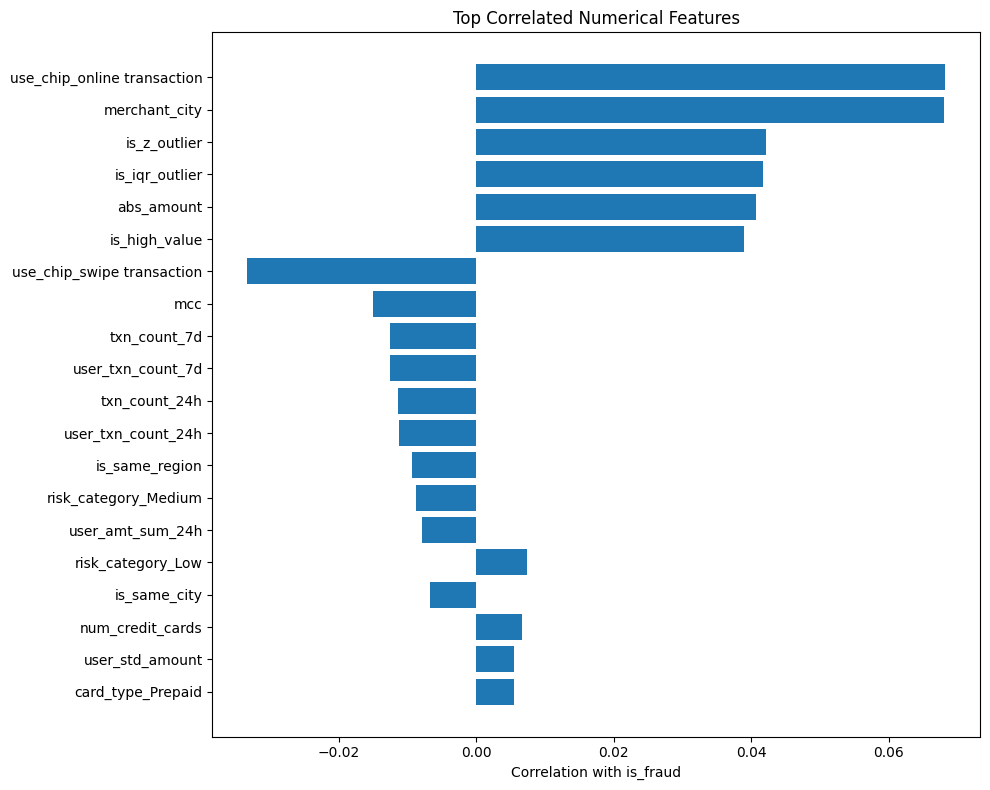

In [24]:
import matplotlib.pyplot as plt

# Take top N features
top_n = 20
corrs_top = corrs.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(corrs_top.index[::-1], corrs_top.values[::-1])
plt.xlabel("Correlation with is_fraud")
plt.title("Top Correlated Numerical Features")
plt.tight_layout()
plt.show()

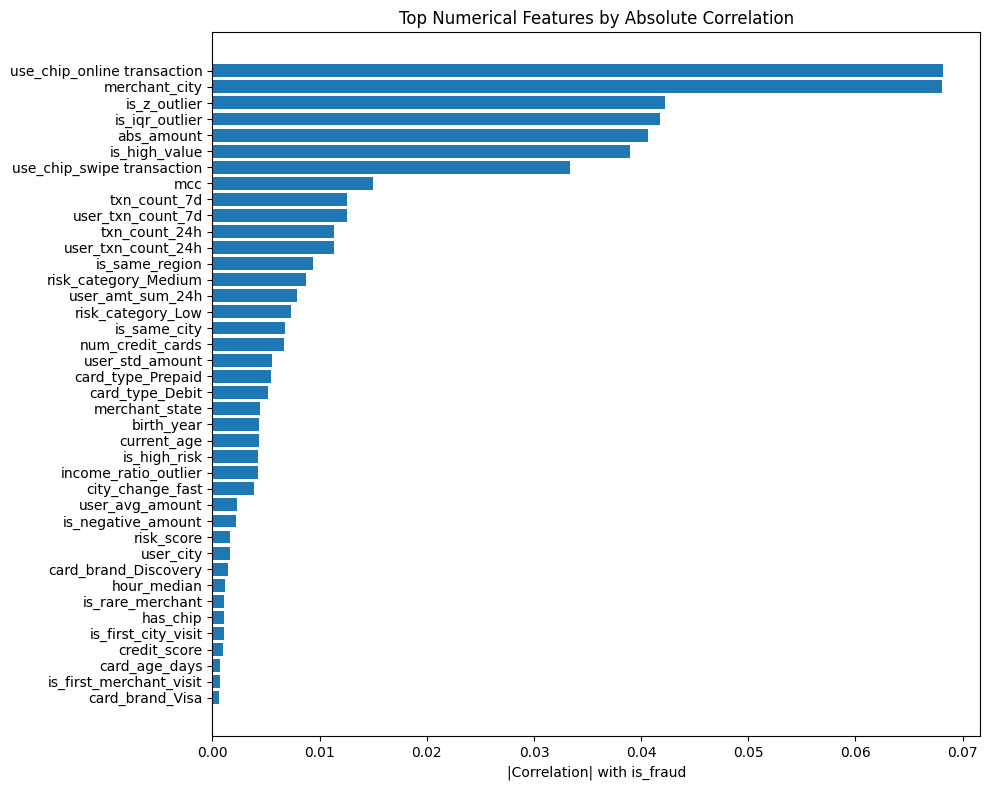

In [27]:
import matplotlib.pyplot as plt
import numpy as np

top_n = 40

corrs_abs = corrs.abs().head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(corrs_abs.index[::-1], corrs_abs.values[::-1])
plt.xlabel("|Correlation| with is_fraud")
plt.title("Top Numerical Features by Absolute Correlation")
plt.tight_layout()
plt.show()


In [28]:
target = "is_fraud"

# 1. Work on TRAIN ONLY
df_corr = df_model  # or X_train.join(y_train)

# 2. Numeric columns ONLY (exclude IDs)
numeric_cols = df_corr.select_dtypes(
    include=["int8", "int16", "int32", "float32", "float64"]
).columns

numeric_cols = [
    c for c in numeric_cols
    if c not in [target, "user_id", "card_id", "merchant_id"]
]

# 3. Downcast for efficiency
df_corr[numeric_cols] = df_corr[numeric_cols].astype("float32")

# 4. Correlation
corrs = (
    df_corr[numeric_cols]
    .corrwith(df_corr[target])
    .abs()
    .sort_values(ascending=False)
)

# 5. Very low threshold (fraud-safe)
corr_selected = corrs[corrs >= 0.003].index.tolist()

print(f"Correlation-kept features: {len(corr_selected)}")


c:\Users\Geeks2_PC10\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Geeks2_PC10\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Correlation-kept features: 21


In [9]:
corr_matrix = df_model[corr_selected].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.85)
]

corr_selected = [c for c in corr_selected if c not in to_drop]

In [29]:
df_model.head(20)

,date,merchant_id,merchant_city,merchant_state,mcc,is_fraud,has_chip,num_cards_issued,credit_limit,acct_open_date,...,city_change_fast,card_type_Debit,card_type_Prepaid,risk_category_Low,risk_category_Medium,card_brand_Discovery,card_brand_Mastercard,card_brand_Visa,use_chip_online transaction,use_chip_swipe transaction
0,2022-01-01 00:46:02,55060,0.073329,0.073329,5812.0,0,1,1.0,316800,2007-09-01,...,0.0,0,0,0,1,0,0,1,0,1
1,2022-01-01 05:02:57,3558,0.073500,0.073500,3640.0,0,1,2.0,566820,2011-02-01,...,0.0,1,0,1,0,0,0,1,0,0
2,2022-01-01 06:04:41,32164,0.073500,0.073500,5813.0,0,1,2.0,566820,2011-02-01,...,0.0,1,0,0,0,0,0,1,0,0
3,2022-01-01 07:49:43,60510,0.073532,0.147060,5912.0,0,1,1.0,316800,2007-09-01,...,0.0,0,0,1,0,0,0,1,0,1
4,2022-01-01 14:07:18,98648,0.073608,0.147231,5814.0,0,1,2.0,566820,2011-02-01,...,0.0,1,0,0,1,0,0,1,0,0
5,2022-01-01 14:46:33,32164,0.073329,0.073329,5813.0,0,1,1.0,316800,2007-09-01,...,1.0,0,0,0,0,0,0,1,0,0
6,2022-01-01 18:12:15,55060,0.073549,0.073549,5812.0,0,1,2.0,566820,2011-02-01,...,0.0,1,0,0,1,0,0,1,0,1
7,2022-01-01 20:00:49,41527,0.073454,0.073454,5310.0,0,1,1.0,316800,2007-09-01,...,0.0,0,0,0,1,0,0,1,0,1
8,2022-01-01 22:34:05,13153,0.073500,0.073500,5812.0,0,1,1.0,316800,2007-09-01,...,0.0,0,0,0,1,0,0,1,0,1
9,2022-01-02 05:03:52,90865,0.073500,0.073500,5311.0,0,1,1.0,316800,2007-09-01,...,0.0,0,0,0,1,0,0,1,0,1


In [30]:
from sklearn.feature_selection import chi2
import pandas as pd
import numpy as np

target = "is_fraud"

# Work on TRAIN only
df_chi = df_model.copy()

# Select numeric columns
numeric_cols = df_chi.select_dtypes(
    include=["int8", "int16", "int32", "int64",
             "float16", "float32", "float64"]
).columns.tolist()

# Remove target + IDs
exclude_cols = [target, "user_id", "card_id", "merchant_id"]
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

# Fill NaN
df_chi[numeric_cols] = df_chi[numeric_cols].fillna(0)

# Ensure non-negative (critical for chi2)
df_chi[numeric_cols] = df_chi[numeric_cols].clip(lower=0)

# Compute chi-square
chi_scores, p_values = chi2(df_chi[numeric_cols], df_chi[target])

chi_df = pd.DataFrame({
    "feature": numeric_cols,
    "chi2_score": chi_scores,
    "p_value": p_values
}).sort_values("chi2_score", ascending=False)

print(chi_df.head(30))

                        feature    chi2_score        p_value
14                   abs_amount  2.739243e+07   0.000000e+00
40             user_amt_sum_24h  3.319642e+06   0.000000e+00
22          amount_to_avg_ratio  3.869311e+05   0.000000e+00
2                           mcc  2.672863e+05   0.000000e+00
21              user_std_amount  4.666860e+04   0.000000e+00
58  use_chip_online transaction  3.539587e+04   0.000000e+00
24                 txn_count_7d  2.472309e+04   0.000000e+00
39            user_txn_count_7d  2.452962e+04   0.000000e+00
36                 is_z_outlier  1.503845e+04   0.000000e+00
35               is_iqr_outlier  1.411871e+04   0.000000e+00
28                is_high_value  1.240601e+04   0.000000e+00
20              user_avg_amount  5.308665e+03   0.000000e+00
59   use_chip_swipe transaction  4.440340e+03   0.000000e+00
23                txn_count_24h  3.497565e+03   0.000000e+00
38           user_txn_count_24h  3.449102e+03   0.000000e+00
19          time_since_l

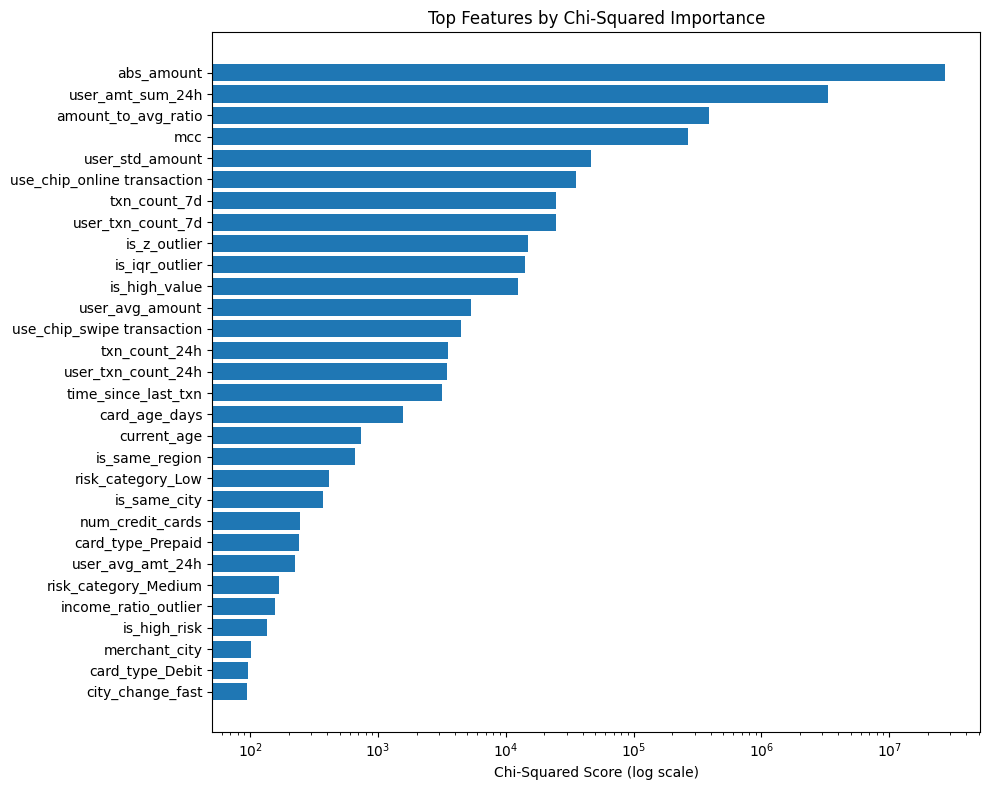

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Sort properly
chi_sorted = chi_df.sort_values("chi2_score", ascending=False)

top_n = 30
chi_top = chi_sorted.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(
    chi_top["feature"][::-1],
    chi_top["chi2_score"][::-1]
)

plt.xscale("log")  # IMPORTANT (huge scale differences)
plt.xlabel("Chi-Squared Score (log scale)")
plt.title("Top Features by Chi-Squared Importance")
plt.tight_layout()
plt.show()

In [46]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# -----------------------------
# 1. Select numeric columns
# -----------------------------
numeric_cols = df_model.select_dtypes(
    include=["int8", "int16", "int32", "int64",
             "float16", "float32", "float64"]
).columns.tolist()

# Remove target + IDs
exclude_cols = [target, "user_id", "card_id", "merchant_id"]
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

# -----------------------------
# 2. Prepare X and y
# -----------------------------
X_num = df_model[numeric_cols].copy()
y = df_model[target]

# -----------------------------
# 3. Ensure non-negative values (REQUIRED for chi²)
# -----------------------------
if (X_num < 0).any().any():
    scaler = MinMaxScaler()
    X_num = pd.DataFrame(
        scaler.fit_transform(X_num),
        columns=numeric_cols
    )

In [47]:
chi_scores, p_values = chi2(X_num, y)

chi_df = pd.DataFrame({
    "feature": numeric_cols,
    "chi2_score": chi_scores,
    "p_value": p_values
}).sort_values("chi2_score", ascending=False)
print(chi_df.head(30))

                        feature    chi2_score        p_value
58  use_chip_online transaction  35395.865173   0.000000e+00
0                 merchant_city  33605.576508   0.000000e+00
36                 is_z_outlier  15038.450349   0.000000e+00
35               is_iqr_outlier  14118.714288   0.000000e+00
28                is_high_value  12406.012075   0.000000e+00
59   use_chip_swipe transaction   4440.340019   0.000000e+00
48               is_same_region    661.440998  7.260268e-146
53            risk_category_Low    414.698827   3.477975e-92
47                 is_same_city    373.785915   2.804750e-83
52            card_type_Prepaid    240.768416   2.673977e-54
14                   abs_amount    230.107419   5.648281e-52
54         risk_category_Medium    168.235692   1.796886e-38
37         income_ratio_outlier    157.230016   4.559200e-36
26                 is_high_risk    136.001881   1.993415e-31
51              card_type_Debit     95.217956   1.705364e-22
50             city_chan

In [50]:
threshold = 40  # tune if needed

chi_selected = chi_df.loc[
    chi_df["chi2_score"] > threshold,
    "feature"
].tolist()

print(f"Keeping {len(chi_selected)} numeric features")
print(chi_selected)


Keeping 23 numeric features
['use_chip_online transaction', 'merchant_city', 'is_z_outlier', 'is_iqr_outlier', 'is_high_value', 'use_chip_swipe transaction', 'is_same_region', 'risk_category_Low', 'is_same_city', 'card_type_Prepaid', 'abs_amount', 'risk_category_Medium', 'income_ratio_outlier', 'is_high_risk', 'card_type_Debit', 'city_change_fast', 'txn_count_7d', 'user_txn_count_7d', 'merchant_state', 'txn_count_24h', 'user_txn_count_24h', 'mcc', 'num_credit_cards']


In [44]:
threshold = 80   # you can tune this

chi_thresh = chi_df.loc[
    chi_df["chi2_score"] > threshold,
    "feature"
].tolist()

print(f"Keeping {len(chi_thresh)} numeric features")
print(chi_thresh)

Keeping 30 numeric features
['abs_amount', 'user_amt_sum_24h', 'amount_to_avg_ratio', 'mcc', 'user_std_amount', 'use_chip_online transaction', 'txn_count_7d', 'user_txn_count_7d', 'is_z_outlier', 'is_iqr_outlier', 'is_high_value', 'user_avg_amount', 'use_chip_swipe transaction', 'txn_count_24h', 'user_txn_count_24h', 'time_since_last_txn', 'card_age_days', 'current_age', 'is_same_region', 'risk_category_Low', 'is_same_city', 'num_credit_cards', 'card_type_Prepaid', 'user_avg_amt_24h', 'risk_category_Medium', 'income_ratio_outlier', 'is_high_risk', 'merchant_city', 'card_type_Debit', 'city_change_fast']


In [45]:
threshold = 80   # you can tune this

chi_selected = chi_df.loc[
    chi_df["chi2_score"] > threshold,
    "feature"
].tolist()

print(f"Keeping {len(chi_selected)} numeric features")
print("Selected binary features:", chi_selected)

Keeping 30 numeric features
Selected binary features: ['abs_amount', 'user_amt_sum_24h', 'amount_to_avg_ratio', 'mcc', 'user_std_amount', 'use_chip_online transaction', 'txn_count_7d', 'user_txn_count_7d', 'is_z_outlier', 'is_iqr_outlier', 'is_high_value', 'user_avg_amount', 'use_chip_swipe transaction', 'txn_count_24h', 'user_txn_count_24h', 'time_since_last_txn', 'card_age_days', 'current_age', 'is_same_region', 'risk_category_Low', 'is_same_city', 'num_credit_cards', 'card_type_Prepaid', 'user_avg_amt_24h', 'risk_category_Medium', 'income_ratio_outlier', 'is_high_risk', 'merchant_city', 'card_type_Debit', 'city_change_fast']


In [34]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8615533 entries, 0 to 8615532
Data columns (total 69 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   date                         datetime64[ns]
 1   merchant_id                  int32         
 2   merchant_city                float32       
 3   merchant_state               float32       
 4   mcc                          float32       
 5   is_fraud                     int8          
 6   has_chip                     int64         
 7   num_cards_issued             float32       
 8   credit_limit                 int32         
 9   acct_open_date               datetime64[ns]
 10  year_pin_last_changed        float32       
 11  card_on_dark_web             int64         
 12  current_age                  float32       
 13  retirement_age               float32       
 14  birth_year                   float32       
 15  birth_month                  float32       
 16  

In [ ]:
'''import pandas as pd
from sklearn.feature_selection import chi2

date_col = df_model['date']
# Identify binary columns (2 unique values, excluding target)
binary_cols = [
    c for c in df_model.columns
    if df_model[c].nunique() == 2 and c != target
]

# Convert Yes/No to 0/1 for all binary columns
for col in binary_cols:
    # Convert string Yes/No to 1/0, leave numeric as-is
    if df_model[col].dtype == object:
        df_model[col] = df_model[col].str.upper().map({"YES": 1, "NO": 0})

# Prepare X and y
X_bin = df_model[binary_cols]
y = df_model[target]

# Run chi2
chi_vals, p_vals = chi2(X_bin, y)

# Create a DataFrame with features and p-values
chi_df = pd.DataFrame({
    "feature": binary_cols,
    "p_value": p_vals
})

# Select features with p-value < 0.01
chi_selected = chi_df.loc[chi_df["p_value"] < 0.01, "feature"].tolist()

print("Selected binary features:", chi_selected)'''

Selected binary features: ['is_negative_amount', 'is_high_value', 'is_iqr_outlier', 'is_z_outlier', 'income_ratio_outlier', 'is_first_city_visit', 'is_rare_merchant', 'is_same_city', 'is_same_region', 'city_change_fast', 'new_city_flag', 'new_city_and_high_value', 'location_mismatch', 'extreme_amt_z', 'off_hours_high_value', 'high_risk_category', 'is_first_category_visit', 'has_error', 'verification_failure', 'balance_issue', 'risky_category_fast', 'new_category_high_value', 'cred_guessing_pattern', 'is_online_txn', 'online_verification_failure', 'online_cred_guess_high_value']


In [12]:
print(X_bin.isna().sum())
print(y.isna().sum())

has_chip                        0
is_negative_amount              0
is_weekend                      0
is_night                        0
is_rush_hour                    0
is_high_value                   0
is_iqr_outlier                  0
is_z_outlier                    0
income_ratio_outlier            0
is_first_merchant_visit         0
is_first_city_visit             0
is_rare_merchant                0
is_same_city                    0
is_same_region                  0
city_changed                    0
city_change_fast                0
new_city_flag                   0
new_city_and_high_value         0
user_merchant_familiarity       0
location_mismatch               0
rapid_repeat_txn                0
extreme_amt_z                   0
off_hours_high_value            0
high_risk_category              0
is_first_category_visit         0
has_error                       0
verification_failure            0
balance_issue                   0
risky_category_fast             0
new_category_h

In [51]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from joblib import Parallel, delayed
import numpy as np


# --- Step 1: Prepare features ---
mi_features = list(set(corr_selected + chi_selected))
X_mi = df_model[mi_features]
y = df_model[target]

# --- Step 2: Parallelized MI computation for all features ---
def compute_mi_vectorized(feature):
    """Compute MI for a single feature using full dataset."""
    return mutual_info_classif(
        X_mi[[feature]], y, discrete_features='auto', random_state=42
    )[0]

# Compute in parallel across all CPU cores
mi_scores = Parallel(n_jobs=-1, verbose=5)(
    delayed(compute_mi_vectorized)(f) for f in mi_features
)

# --- Step 3: Create MI dataframe and select top features ---
mi_df = pd.DataFrame({
    "feature": mi_features,
    "mi_score": mi_scores
}).sort_values("mi_score", ascending=False)

# Keep top 60% features (or adjust quantile)
mi_selected = mi_df.loc[
    mi_df["mi_score"] >= mi_df["mi_score"].quantile(0.4),
    "feature"
].tolist()

print(f"Selected {len(mi_selected)} features out of {len(mi_features)}")
print("Selected features based on MI:", mi_selected)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  27 | elapsed:  4.2min remaining:  7.2min
[Parallel(n_jobs=-1)]: Done  16 out of  27 | elapsed:  7.6min remaining:  5.2min
[Parallel(n_jobs=-1)]: Done  22 out of  27 | elapsed:  8.3min remaining:  1.9min


Selected 16 features out of 27
Selected features based on MI: ['num_credit_cards', 'merchant_state', 'merchant_city', 'mcc', 'user_txn_count_24h', 'txn_count_24h', 'current_age', 'use_chip_online transaction', 'risk_category_Low', 'is_same_region', 'birth_year', 'is_high_risk', 'txn_count_7d', 'user_txn_count_7d', 'is_iqr_outlier', 'card_type_Prepaid']


[Parallel(n_jobs=-1)]: Done  27 out of  27 | elapsed:  9.5min finished


In [54]:
# 1. Combine selected features (union)
selected_features = list(set(corr_selected + chi_selected))
print(f"Total features after combining: {len(selected_features)}")

# 2. Include the target column
selected_features.append(target)

# 3. Create the new dataset
df_selected = df_model[selected_features].copy()

# 4. Quick check
print("Columns in the new dataset:", df_selected.columns.tolist())
print("Shape of the new dataset:", df_selected.shape)

Total features after combining: 27
Columns in the new dataset: ['user_std_amount', 'abs_amount', 'risk_category_Medium', 'txn_count_24h', 'use_chip_swipe transaction', 'user_txn_count_24h', 'num_credit_cards', 'birth_year', 'is_same_city', 'user_txn_count_7d', 'merchant_city', 'txn_count_7d', 'is_z_outlier', 'mcc', 'is_high_value', 'current_age', 'income_ratio_outlier', 'card_type_Debit', 'is_iqr_outlier', 'city_change_fast', 'user_amt_sum_24h', 'risk_category_Low', 'card_type_Prepaid', 'use_chip_online transaction', 'is_high_risk', 'is_same_region', 'merchant_state', 'is_fraud']
Shape of the new dataset: (8615533, 28)


In [55]:
df_selected.head()

,user_std_amount,abs_amount,risk_category_Medium,txn_count_24h,use_chip_swipe transaction,user_txn_count_24h,num_credit_cards,birth_year,is_same_city,user_txn_count_7d,...,is_iqr_outlier,city_change_fast,user_amt_sum_24h,risk_category_Low,card_type_Prepaid,use_chip_online transaction,is_high_risk,is_same_region,merchant_state,is_fraud
0,0.000000,179.279999,1,1.0,1,0.0,4.0,1986.0,0.0,0.0,...,0.0,0.0,0.000000,0,0,0,0.0,0.0,0.073329,0
1,0.000000,5724.000000,0,2.0,0,1.0,4.0,1986.0,0.0,1.0,...,1.0,0.0,179.279999,1,0,0,0.0,0.0,0.073500,0
2,3920.708984,987.119995,0,3.0,0,2.0,4.0,1986.0,0.0,2.0,...,0.0,0.0,5903.279785,0,0,0,1.0,0.0,0.073500,0
3,2995.400879,279.179993,0,4.0,1,3.0,4.0,1986.0,0.0,3.0,...,0.0,0.0,6890.399902,1,0,0,0.0,0.0,0.147060,0
4,2645.622070,138.600006,1,5.0,0,4.0,4.0,1986.0,0.0,4.0,...,0.0,0.0,7169.580078,0,0,0,0.0,0.0,0.147231,0


In [12]:
X_mi.head(10)

,is_negative_amount,is_same_region,is_high_value,mcc,new_category_high_value,txn_count_7d,off_hours_high_value,has_error,is_iqr_outlier,txn_count_24h,...,income_ratio_outlier,online_verification_failure,verification_failure,city_change_fast,category_amt_ratio,is_first_city_visit,extreme_amt_z,high_risk_category,is_first_category_visit,is_z_outlier
0,0.0,0.0,0.0,5499.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.307187,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,5310.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.136369,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,5411.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.089740,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,5310.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.626763,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,5541.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.132529,0.0,0.0,0.0,1.0,0.0
5,0.0,0.0,0.0,5541.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.395503,0.0,0.0,0.0,1.0,0.0
6,0.0,0.0,0.0,5311.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.704850,0.0,0.0,0.0,1.0,0.0
7,0.0,0.0,0.0,5813.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.223940,0.0,0.0,0.0,1.0,0.0
8,0.0,0.0,0.0,5942.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.584594,0.0,0.0,0.0,1.0,0.0
9,0.0,0.0,0.0,5411.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,4.594162,0.0,0.0,0.0,1.0,0.0


In [13]:
X_mi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8615533 entries, 0 to 8615532
Data columns (total 31 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   is_negative_amount            float32
 1   is_same_region                float32
 2   is_high_value                 float32
 3   mcc                           float32
 4   new_category_high_value       float32
 5   txn_count_7d                  float32
 6   off_hours_high_value          float32
 7   has_error                     float32
 8   is_iqr_outlier                float32
 9   txn_count_24h                 float32
 10  balance_issue                 float32
 11  risky_category_fast           float32
 12  new_city_and_high_value       float32
 13  is_rare_merchant              float32
 14  is_same_city                  float32
 15  new_city_flag                 float32
 16  is_online_txn                 float32
 17  location_mismatch             float32
 18  online_cred_guess_high

In [14]:
X_mi['off_hours_high_value'].value_counts()

off_hours_high_value
0.0    8453820
1.0     161713
Name: count, dtype: int64

In [52]:
final_features = mi_selected

In [53]:
pd.Series(final_features).head(10)

0               num_credit_cards
1                 merchant_state
2                  merchant_city
3                            mcc
4             user_txn_count_24h
5                  txn_count_24h
6                    current_age
7    use_chip_online transaction
8              risk_category_Low
9                 is_same_region
dtype: object

In [17]:
X_final = df_model[mi_selected]
y = df_model[target]

In [18]:
X_final.head(20)

,mcc,txn_count_24h,is_online_txn,is_same_region,is_rare_merchant,high_risk_category,txn_count_7d,is_iqr_outlier,is_same_city,is_high_value,is_negative_amount,new_city_and_high_value,is_z_outlier,off_hours_high_value,extreme_amt_z,has_error,is_first_category_visit,balance_issue,abs_amount
0,5499.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,47.160000
1,5310.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,123.120003
2,5411.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,25.559999
3,5310.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,527.400024
4,5541.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,55.439999
5,5541.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,269.820007
6,5311.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,700.020020
7,5813.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,641.159973
8,5942.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,90.180000
9,5411.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1501.020020


In [57]:
# 1. Split first
X = df_selected.drop(columns=[target])
y = df_selected[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=False
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (6461649, 27)
Test shape: (2153884, 27)


In [58]:
y_train.shape, y_test.shape

((6461649,), (2153884,))

In [21]:
y_test.value_counts()

is_fraud
0    1720533
1       2574
Name: count, dtype: int64

In [ ]:
'''from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit

pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

lgbm = lgb.LGBMClassifier(
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=255,
    min_data_in_leaf=30,
    feature_fraction=0.9,
    bagging_fraction=0.8,
    bagging_freq=5,
    scale_pos_weight=pos_weight,
    max_bin=255,           # 500 is unnecessary & memory-heavy
    force_row_wise=True,
    n_jobs=-1,
    random_state=42
)

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,           # 10 is often too deep for fraud
    subsample=0.7,
    colsample_bytree=0.9,
    scale_pos_weight=pos_weight,
    eval_metric="aucpr",   # IMPORTANT for fraud
    gamma=1,
    min_child_weight=5,    # stronger regularization
    reg_alpha=1.0,
    reg_lambda=2.0,
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)


#rf = RandomForestClassifier(
#    n_estimators=150,
#    max_depth=10,
#    class_weight="balanced",
#    random_state=42
#)
base_models = [
    ('lgbm', lgbm),
    ('xgb_model', xgb_model),
#    ('rf', rf)
]

meta_learner = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        C=0.1,              # strong regularization
        penalty="l2",
        max_iter=3000,
        solver="lbfgs",
        n_jobs=-1
    ))
])


stacked_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv = TimeSeriesSplit(n_splits=4),
    n_jobs=1,
    passthrough=False,
    stack_method="predict_proba"
)'''

In [64]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
import gc

pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
lgbm = lgb.LGBMClassifier(
    n_estimators=800,             # large but early stopping will trim
    learning_rate=0.05,
    num_leaves=128,                # reduce from 255
    max_depth=8,                   # prevent deep memory-heavy trees
    min_data_in_leaf=50,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    scale_pos_weight=pos_weight,
    max_bin=255,
    force_row_wise=True,
    n_jobs=-1,
    random_state=42
)

xgb_model = xgb.XGBClassifier(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=6,                   # reduce depth
    subsample=0.7,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    eval_metric="aucpr",
    tree_method="hist",
    max_bin=256,
    gamma=1,
    min_child_weight=10,
    reg_alpha=1.0,
    reg_lambda=2.0,
    n_jobs=-1,
    random_state=42
)

In [65]:
base_models = [
    ('lgbm', lgbm),
    ('xgb_model', xgb_model),
#    ('rf', rf)
]

In [66]:
meta_learner = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        C=0.1,              # strong regularization
        penalty="l2",
        max_iter=3000,
        solver="lbfgs",
        n_jobs=-1
    ))
])

In [67]:
# 2. Stacking classifier with logistic regression as meta-learner
stacked_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=StratifiedKFold(n_splits=5, shuffle=False),   # preserves temporal order
    n_jobs=-1,
    passthrough=True    # pass original features to meta-learner
)

# 3. Optional: Wrap in pipeline with scaler if needed
# For trees, scaling is not necessary, but if you add LR as a base model you may scale
pipeline = Pipeline([
    ("stacked", stacked_model)
])

In [68]:
# 4. Fit on training data
pipeline.fit(X_train, y_train)

# 5. Predict probabilities on test set
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

LightGBMError: bad allocation

In [69]:
from lightgbm import early_stopping, log_evaluation
from xgboost.callback import EarlyStopping

tscv = TimeSeriesSplit(n_splits=3)

oof_lgb = np.zeros(len(X_train), dtype=np.float32)
oof_xgb = np.zeros(len(X_train), dtype=np.float32)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

    print(f"\nFold {fold+1}")

    X_tr = X_train.iloc[train_idx]
    y_tr = y_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_val = y_train.iloc[val_idx]

    # ---- LightGBM ----
    lgbm.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="average_precision",
        callbacks=[
            early_stopping(100),
            log_evaluation(0)
        ]
    )

    oof_lgb[val_idx] = lgbm.predict_proba(X_val)[:, 1].astype(np.float32)

# ---- XGBoost (v2.x correct) ----
# ---- XGBoost (3.1.3 correct) ----
    xgb_model.set_params(early_stopping_rounds=100)

    xgb_model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    oof_xgb[val_idx] = xgb_model.predict_proba(X_val)[:, 1].astype(np.float32)
    gc.collect()



Fold 1
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. 

In [24]:
import xgboost
print(xgboost.__version__)

3.1.3


In [70]:
from sklearn.linear_model import LogisticRegression

meta_X = np.column_stack((oof_lgb, oof_xgb)).astype(np.float32)

meta_model = LogisticRegression(
    C=0.1,
    penalty="l2",
    max_iter=2000,
    class_weight="balanced"
)

meta_model.fit(meta_X, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [ ]:
lgbm.fit(X_train, y_train)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current 

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,100
,enable_categorical,False
,eval_metric,'aucpr'


In [75]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

# -------------------------------
# 1. Get predicted probabilities from each model
# -------------------------------
y_pred_proba_lgb = lgbm.predict_proba(X_test)[:, 1]
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# -------------------------------
# 2. Combine predictions (simple average)
# -------------------------------
y_pred_proba_ensemble = (y_pred_proba_lgb + y_pred_proba_xgb) / 2

# -------------------------------
# 3. Evaluate ensemble
# -------------------------------
roc_auc_ens = roc_auc_score(y_test, y_pred_proba_ensemble)
pr_auc_ens  = average_precision_score(y_test, y_pred_proba_ensemble)

# Confusion matrix at default 0.5 threshold
y_pred_ens = (y_pred_proba_ensemble >= 0.5).astype(int)
cm_ens = confusion_matrix(y_test, y_pred_ens)

print(f"Ensemble ROC AUC: {roc_auc_ens:.4f}")
print(f"Ensemble PR AUC: {pr_auc_ens:.4f}")
print("Ensemble Confusion Matrix:\n", cm_ens)


[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
Ensemble ROC AUC: 0.9327
Ensemble PR AUC: 0.3517
Ensemble Confusion Matrix:
 [[1867911  282758]
 [    781    2434]]


In [72]:
def stacked_predict_proba(X):

    X = X.astype("float32")

    lgb_pred = lgbm.predict_proba(X)[:, 1]
    xgb_pred = xgb_model.predict_proba(X)[:, 1]

    meta_input = np.column_stack((lgb_pred, xgb_pred))
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
    return meta_model.predict_proba(meta_input)[:, 1]

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

stacked_model.fit(X_train, y_train)

In [ ]:
y_pred_proba = stacked_model.predict_proba(X_test)[:, 1]

=== Classification Report (threshold=0.5) ===
              precision    recall  f1-score   support

           0       1.00      0.87      0.93   2150669
           1       0.01      0.76      0.02      3215

    accuracy                           0.87   2153884
   macro avg       0.50      0.81      0.47   2153884
weighted avg       1.00      0.87      0.93   2153884

ROC-AUC: 0.9327
PR-AUC: 0.3517
Confusion Matrix:
 [[1867911  282758]
 [    781    2434]]


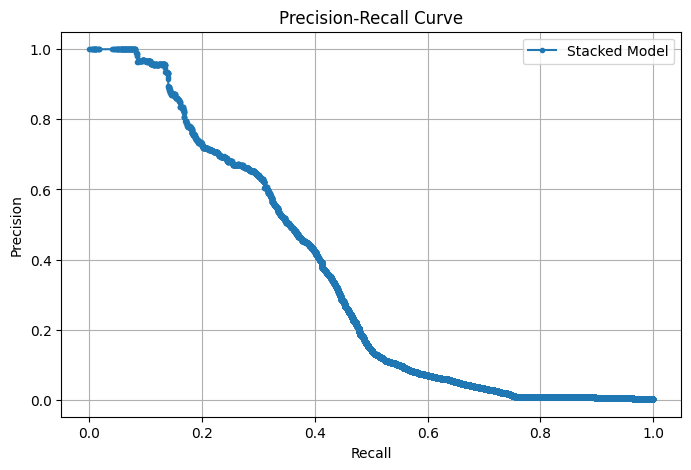

Optimal Threshold for max F1-score: 0.9759
Max F1-score at this threshold: 0.4157
=== Classification Report (optimal threshold) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2150669
           1       0.45      0.39      0.42      3215

    accuracy                           1.00   2153884
   macro avg       0.72      0.69      0.71   2153884
weighted avg       1.00      1.00      1.00   2153884

Confusion Matrix (Optimal Threshold):
 [[2149128    1541]
 [   1967    1248]]


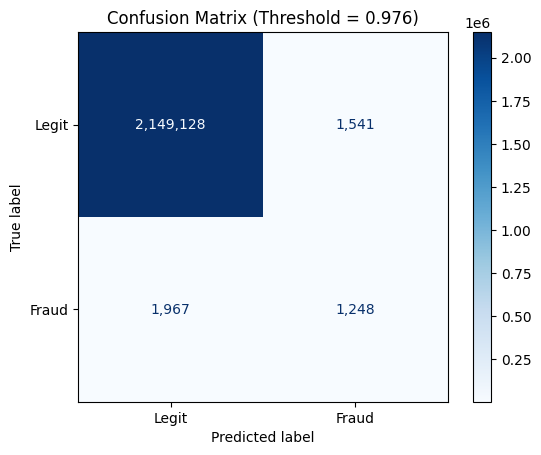

In [77]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score
)
import matplotlib.pyplot as plt
import numpy as np



# Step 2: Default predictions (threshold 0.5)
y_pred_default = (y_pred_proba_ensemble >= 0.5).astype(int)


# Step 3: Metrics
print("=== Classification Report (threshold=0.5) ===")
print(classification_report(y_test, y_pred_default))

roc_auc = roc_auc_score(y_test, y_pred_proba_ensemble)
print(f"ROC-AUC: {roc_auc:.4f}")

pr_auc = average_precision_score(y_test, y_pred_proba_ensemble)
print(f"PR-AUC: {pr_auc:.4f}")

cm = confusion_matrix(y_test, y_pred_default)
print("Confusion Matrix:\n", cm)


# Step 4: Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_ensemble)

plt.figure(figsize=(8,5))
plt.plot(recall, precision, marker='.', label='Stacked Model')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()



# Step 5: Find optimal threshold by maximizing F1-score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)  # avoid division by zero
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal Threshold for max F1-score: {best_threshold:.4f}")
print(f"Max F1-score at this threshold: {best_f1:.4f}")

# Predictions at optimal threshold
y_pred_opt = (y_pred_proba_ensemble >= best_threshold).astype(int)
print("=== Classification Report (optimal threshold) ===")
print(classification_report(y_test, y_pred_opt))

cm_opt = confusion_matrix(y_test, y_pred_opt)
print("Confusion Matrix (Optimal Threshold):\n", cm_opt)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_opt,
    display_labels=['Legit', 'Fraud']
)

disp.plot(cmap='Blues', values_format=',')
plt.title(f'Confusion Matrix (Threshold = {best_threshold:.3f})')
plt.show()

ROC-AUC: 0.9420
PR-AUC : 0.5191



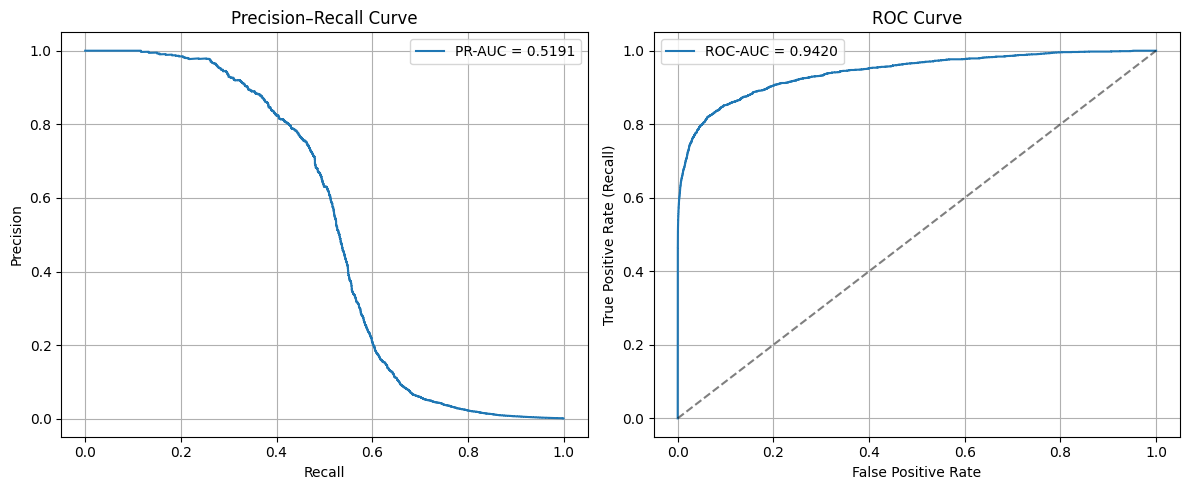

KeyboardInterrupt: 

In [44]:
df_thresholds = run_threshold_analysis(
    y_test=y_test,
    y_pred_proba=y_pred_proba,
    thresholds="prcurve",    # evaluates model’s natural thresholds
    min_precision=0.20,      # adjust to investigation capacity
    min_recall=0.70,         # ensure sufficient fraud catch rate
    cost_fn=15000.0,         # your estimated loss per missed fraud
    cost_fp=30.0,            # your investigation cost per false alarm
    export_csv_path="threshold_analysis.csv"
)

In [45]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

=== Classification Report (threshold=0.5) ===
              precision    recall  f1-score   support

           0       1.00      0.93      0.96   1720533
           1       0.02      0.82      0.03      2574

    accuracy                           0.93   1723107
   macro avg       0.51      0.88      0.50   1723107
weighted avg       1.00      0.93      0.96   1723107

ROC-AUC: 0.9420
PR-AUC: 0.5191


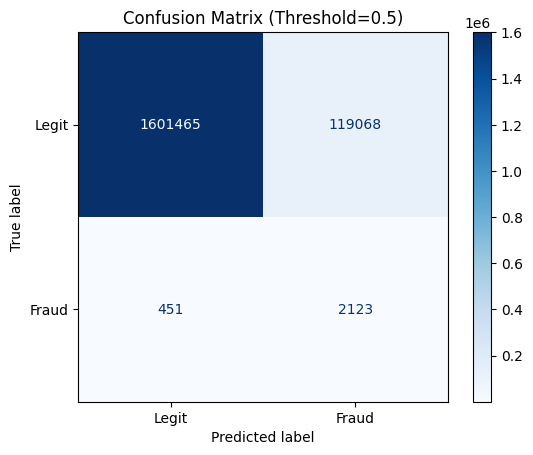

In [46]:
# Default threshold
y_pred_default = (y_pred_proba >= 0.5).astype(int)

# Metrics
print("=== Classification Report (threshold=0.5) ===")
print(classification_report(y_test, y_pred_default))

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_default)
disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix (Threshold=0.5)")
plt.show()

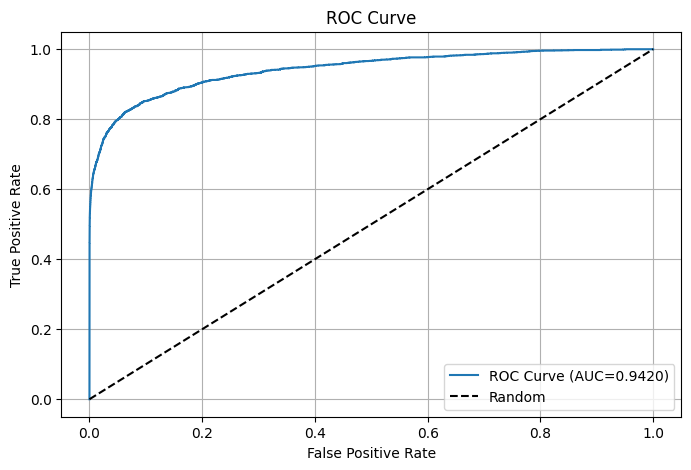

In [47]:
fpr, tpr, roc_thresh = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC={roc_auc:.4f})')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

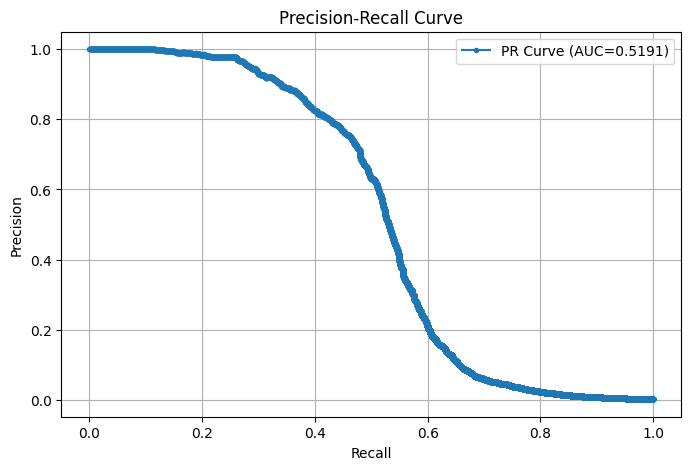

In [48]:
precision, recall, pr_thresh = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,5))
plt.plot(recall, precision, marker='.', label=f'PR Curve (AUC={pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

Optimal Threshold (max F1): 0.9994
Max F1-score: 0.5733
=== Classification Report (optimal threshold) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1720533
           1       0.74      0.47      0.57      2574

    accuracy                           1.00   1723107
   macro avg       0.87      0.73      0.79   1723107
weighted avg       1.00      1.00      1.00   1723107



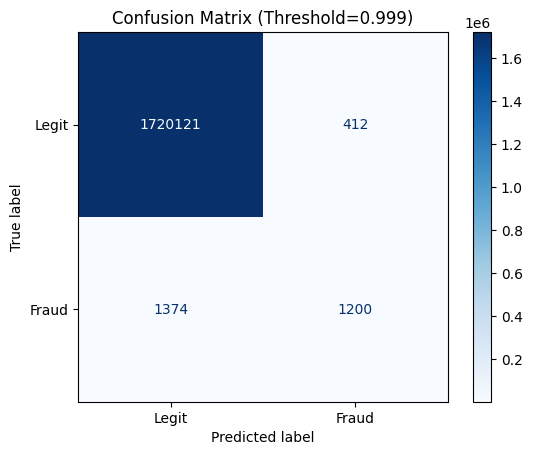

In [49]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = pr_thresh[best_idx]  # note: precision_recall_curve thresholds
best_f1 = f1_scores[best_idx]

print(f"Optimal Threshold (max F1): {best_threshold:.4f}")
print(f"Max F1-score: {best_f1:.4f}")

# Predictions at optimal threshold
y_pred_opt = (y_pred_proba >= best_threshold).astype(int)
print("=== Classification Report (optimal threshold) ===")
print(classification_report(y_test, y_pred_opt))

cm_opt = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(cm_opt, display_labels=['Legit', 'Fraud'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix (Threshold={best_threshold:.3f})')
plt.show()

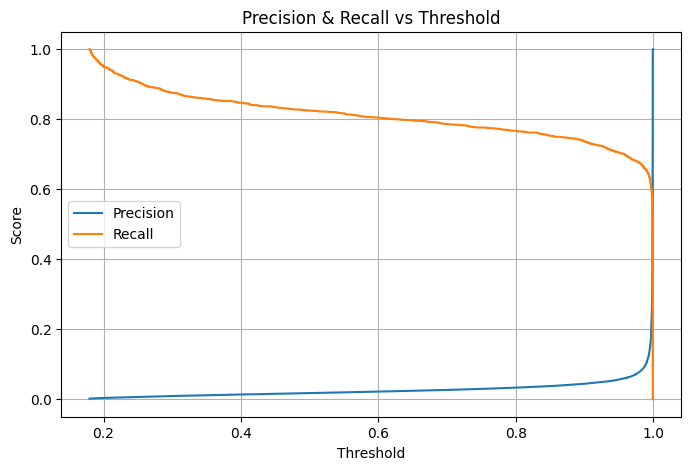

In [62]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, precision, label='Precision')
plt.plot(thresholds, recall, label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

Selected threshold for target recall=0.51: 0.9601
Precision at this threshold: 0.1263
Recall at this threshold: 0.5101
F1-score at this threshold: 0.2024


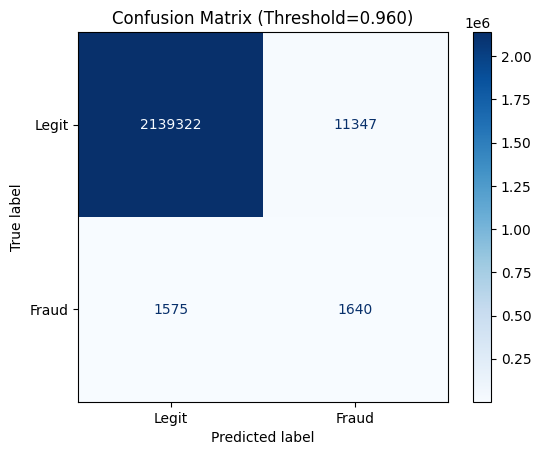

In [78]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_ensemble)

# Add last threshold (precision_recall_curve omits last)
thresholds = np.append(thresholds, 1.0)

# Target: maximize recall for fraud with acceptable precision
target_recall = 0.51  # adjust as needed
idx = np.argmin(np.abs(recall - target_recall))
best_threshold = thresholds[idx]

print(f"Selected threshold for target recall={target_recall}: {best_threshold:.4f}")
print(f"Precision at this threshold: {precision[idx]:.4f}")
print(f"Recall at this threshold: {recall[idx]:.4f}")
print(f"F1-score at this threshold: {2*(precision[idx]*recall[idx])/(precision[idx]+recall[idx]+1e-8):.4f}")

# Predictions at new threshold
y_pred_new = (y_pred_proba_ensemble >= best_threshold).astype(int)
cm_new = confusion_matrix(y_test, y_pred_new)

disp = ConfusionMatrixDisplay(cm_new, display_labels=['Legit', 'Fraud'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix (Threshold={best_threshold:.3f})')
plt.show()

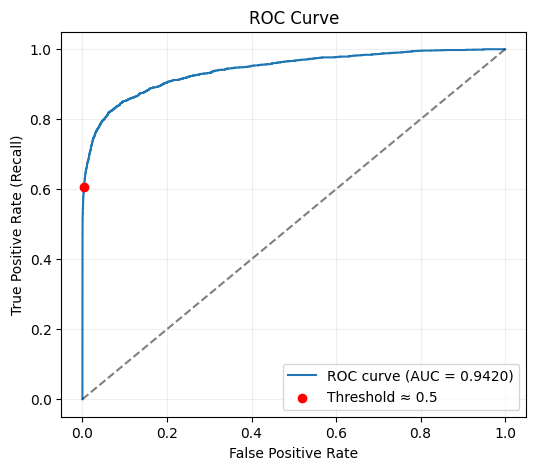

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve

fpr, tpr, thr_roc = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# find the point on the ROC curve closest to threshold=0.5
# (not exact match because thresholds are derived from scores)
idx_05 = np.argmin(np.abs(thr_roc - 0.9972))

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.scatter(fpr[idx_05], tpr[idx_05], color="red", zorder=3, label="Threshold ≈ 0.5")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [35]:
feature_names = X_train_final.columns
lgbm_model = stacked_model.named_estimators_['lgbm']
xgb_model  = stacked_model.named_estimators_['xgb_model']

lgbm_importance = lgbm_model.feature_importances_
xgb_importance = xgb_model.feature_importances_

lgbm_norm = lgbm_importance / (lgbm_importance.sum() + 1e-8)
xgb_norm  = xgb_importance  / (xgb_importance.sum()  + 1e-8)

combined_importance = (lgbm_norm + xgb_norm) / 2

In [36]:
importance_df = pd.DataFrame({
    'feature': feature_names,
    'LGBM_importance': lgbm_norm,
    'XGB_importance': xgb_norm,
    'combined_importance': combined_importance
})

importance_df = importance_df.sort_values(
    by='combined_importance',
    ascending=False
)

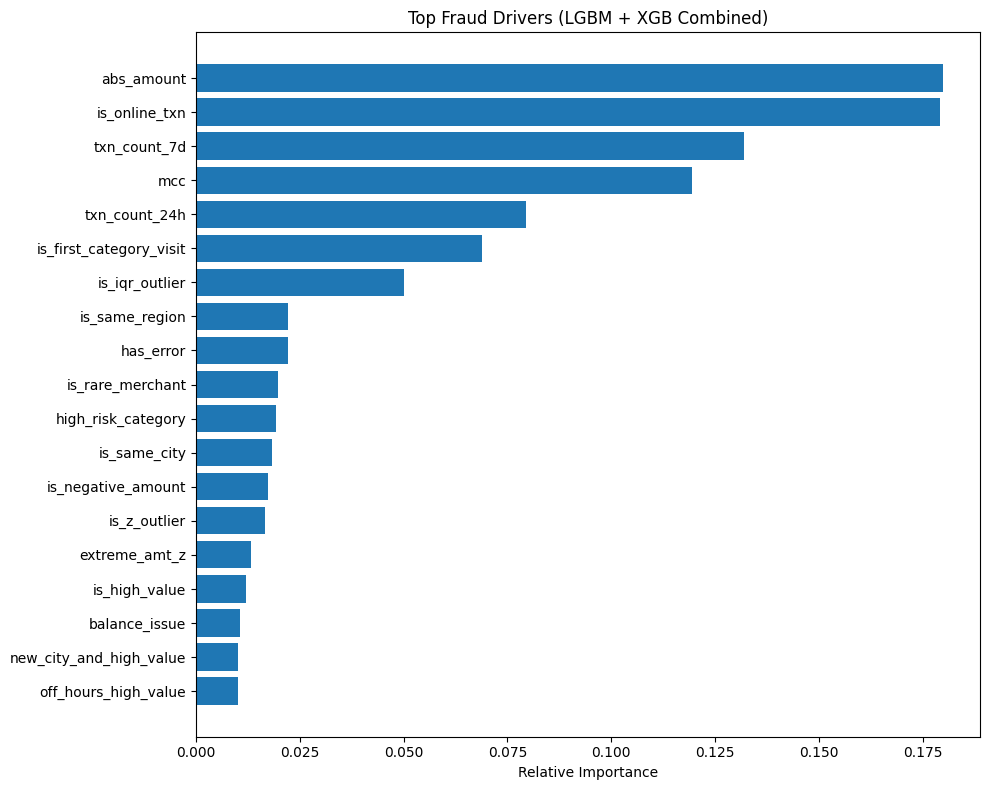

In [39]:
import matplotlib.pyplot as plt

top_50 = importance_df.head(50)

plt.figure(figsize=(10, 8))
plt.barh(
    top_50['feature'][::-1],
    top_50['combined_importance'][::-1]
)
plt.xlabel('Relative Importance')
plt.title('Top Fraud Drivers (LGBM + XGB Combined)')
plt.tight_layout()
plt.show()

In [38]:
print("Top 60 Fraud Drivers:")
print(importance_df.head(60).to_string(index=False))

Top 60 Fraud Drivers:
                feature  LGBM_importance  XGB_importance  combined_importance
             abs_amount         0.319429        0.040216             0.179822
          is_online_txn         0.028770        0.329644             0.179207
           txn_count_7d         0.235901        0.028002             0.131951
                    mcc         0.166713        0.071937             0.119325
          txn_count_24h         0.134852        0.023838             0.079345
is_first_category_visit         0.014370        0.123119             0.068744
         is_iqr_outlier         0.011403        0.088793             0.050098
         is_same_region         0.016216        0.028163             0.022189
              has_error         0.009582        0.034502             0.022042
       is_rare_merchant         0.018386        0.021248             0.019817
     high_risk_category         0.007982        0.030374             0.019178
           is_same_city         0.009946  

In [76]:
X_train_final.head(10)

,mcc,txn_count_24h,is_online_txn,is_same_region,is_rare_merchant,high_risk_category,txn_count_7d,is_iqr_outlier,is_same_city,is_high_value,is_negative_amount,new_city_and_high_value,is_z_outlier,off_hours_high_value,extreme_amt_z,has_error,is_first_category_visit,balance_issue,abs_amount
0,5499.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,47.160000
1,5310.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,123.120003
2,5411.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,25.559999
3,5310.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,527.400024
4,5541.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,55.439999
5,5541.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,269.820007
6,5311.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,700.020020
7,5813.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,641.159973
8,5942.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,90.180000
9,5411.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1501.020020


In [77]:
import joblib

export_object = {
    "model": stacked_model,         # your stacked or calibrated model
    "threshold": f"{best_threshold:.3f}",    # e.g. 0.999 or your chosen balanced threshold
    "features": X_train_final.columns.tolist(),  # to maintain correct column order
}

joblib.dump(export_object, "fraud_model_with_threshold.pkl")

print("Model exported successfully.")

Model exported successfully.
